In [1]:
# ============================================
# Setup Colab: GPU + Drive
# ============================================

import os
from pathlib import Path

COLAB = "google.colab" in str(get_ipython())

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    !nvidia-smi
else:
    print("Running locally")

Mounted at /content/drive
Thu Apr 16 13:52:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+---------------------

In [2]:
# ============================================
# Paths configuration
# ============================================

if COLAB:
    DRIVE_ROOT = Path("/content/drive/MyDrive/bootcamp_project/data/")
    LOCAL_SSD_ROOT = Path("/content/dataset")

    # Dataset source on Drive
    DRIVE_DATASET_DIR = DRIVE_ROOT

    # Dataset destination on SSD
    LOCAL_DATASET_DIR = LOCAL_SSD_ROOT

    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)

    print("Drive dataset:", DRIVE_DATASET_DIR)
    print("Local SSD dataset:", LOCAL_DATASET_DIR)

Drive dataset: /content/drive/MyDrive/bootcamp_project/data
Local SSD dataset: /content/dataset


### Optimize Dataset Copying with Tarball

Copying many small files can be inefficient. To speed up the process and make it more robust across Colab sessions, we'll create a single compressed archive (tar.gz) of the dataset on Google Drive. This archive will be created only once. In subsequent runs, we'll just copy this single tarball to the local SSD and extract it, which is significantly faster than copying individual files. We'll also check if the local dataset is already present to avoid unnecessary operations.

In [3]:
import shutil

tar_filename = "dataset.tar.gz"
DRIVE_TAR_PATH = DRIVE_DATASET_DIR / tar_filename
LOCAL_TAR_PATH = LOCAL_SSD_ROOT / tar_filename

if COLAB:
    print("\n--- Optimizing Dataset Loading ---")
    print("Checking for dataset tarball on Drive...")
    if not DRIVE_TAR_PATH.exists():
        print(f"Creating tarball '{tar_filename}' from '{DRIVE_DATASET_DIR.name}' in '{DRIVE_DATASET_DIR.parent}'...")
        # Create a tar.gz archive of the dataset directory
        shutil.make_archive(
            str(DRIVE_TAR_PATH.with_suffix('')), # make_archive adds .tar.gz itself
            'gztar',
            root_dir=DRIVE_DATASET_DIR.parent, # The directory containing the folder to archive
            base_dir=DRIVE_DATASET_DIR.name   # The folder to archive
        )
        print(f"✓ Tarball created at {DRIVE_TAR_PATH}")
    else:
        print(f"✓ Tarball already exists at {DRIVE_TAR_PATH}")

    # Check if LOCAL_DATASET_DIR is already populated to skip re-extraction
    # This is useful if a previous run in the same session already extracted the data
    if LOCAL_DATASET_DIR.exists() and any(LOCAL_DATASET_DIR.iterdir()): # Check if directory exists and is not empty
        print("✓ Local dataset directory is already populated. Skipping tarball extraction.")
    else:
        print(f"Copying tarball from Drive to local SSD: {DRIVE_TAR_PATH} -> {LOCAL_TAR_PATH}")
        shutil.copy2(DRIVE_TAR_PATH, LOCAL_TAR_PATH)
        print(f"✓ Tarball copied to local SSD.")

        print(f"Extracting tarball to {LOCAL_SSD_ROOT}...")
        shutil.unpack_archive(LOCAL_TAR_PATH, LOCAL_SSD_ROOT)
        print(f"✓ Tarball extracted.")

        # Clean up the copied tarball to save space on SSD
        LOCAL_TAR_PATH.unlink()
        print(f"✓ Local tarball removed: {LOCAL_TAR_PATH}")

    print("--- Dataset loading optimization complete ---")
else:
    print("Local run — no tarball needed.")


--- Optimizing Dataset Loading ---
Checking for dataset tarball on Drive...
✓ Tarball already exists at /content/drive/MyDrive/bootcamp_project/data/dataset.tar.gz
Copying tarball from Drive to local SSD: /content/drive/MyDrive/bootcamp_project/data/dataset.tar.gz -> /content/dataset/dataset.tar.gz
✓ Tarball copied to local SSD.
Extracting tarball to /content/dataset...
✓ Tarball extracted.
✓ Local tarball removed: /content/dataset/dataset.tar.gz
--- Dataset loading optimization complete ---


In [4]:
! pip install -q timm

In [5]:
# ============================================
# Imports
# ============================================

import os
import glob
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

import timm
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [6]:
# ============================================
# Login to Weights & Biases
# ============================================

import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jimmy-ouellet (jimmy-ouellet-personnal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
# ============================================
# Data Augmentation (per-model image size)
# ============================================
# Each architecture expects a different input resolution.
# get_transforms() creates matching train/val pipelines on the fly.

def get_transforms(img_size: int):
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_transforms, val_transforms

In [29]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# === CONFIG ===
DATASET_DIR = Path("/content/dataset/dataset/")  # dossier avec 1 classe = 1 dossier
SPLIT_DIR   = Path("/content/dataset_split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

classes = sorted([
    d.name for d in DATASET_DIR.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print(f"{len(classes)} classes détectées.")
print(classes)

for cls in tqdm(classes, desc="Splitting classes"):
    print(cls)
    src = DATASET_DIR / cls
    print(src)
    images = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    # Split 80% train / 20% val
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class folders
    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (VAL_DIR / cls).mkdir(parents=True, exist_ok=True)

    # Copy images
    for img in train_imgs:
        shutil.copy2(src / img, TRAIN_DIR / cls / img)

    for img in val_imgs:
        shutil.copy2(src / img, VAL_DIR / cls / img)

print("✓ Split terminé.")
print("Train dir :", TRAIN_DIR)
print("Val dir   :", VAL_DIR)

58 classes détectées.
['allium', 'angelica', 'apple', 'avocado', 'basil', 'bird_of_paradise', 'blackberry', 'blueberry', 'borage', 'chamomile', 'cherry', 'chives', 'chrysanthemum', 'coriander', 'cosmos', 'cranberry', 'daisy', 'dill', 'fennel', 'fig', 'foxglove', 'freesia', 'gerbera', 'grape', 'gypsophila', 'hellebore', 'hydrangea', 'hyssop', 'iris', 'kiwi', 'lavender', 'lemon', 'lemongrass', 'lemonverbena', 'lily', 'lisianthus', 'lovage', 'mango', 'melon', 'mint', 'mugwort', 'oregano', 'parsley', 'peach', 'pear', 'poppy', 'ranunculus', 'raspberry', 'rosemary', 'sage', 'savory', 'strawberry', 'sunflower', 'tarragon', 'thyme', 'wintergreen', 'wisteria', 'zinnia']


Splitting classes:   3%|▎         | 2/58 [00:00<00:03, 16.98it/s]

allium
/content/dataset/dataset/allium
angelica
/content/dataset/dataset/angelica
apple
/content/dataset/dataset/apple
avocado
/content/dataset/dataset/avocado


Splitting classes:  10%|█         | 6/58 [00:00<00:03, 16.91it/s]

basil
/content/dataset/dataset/basil
bird_of_paradise
/content/dataset/dataset/bird_of_paradise
blackberry
/content/dataset/dataset/blackberry
blueberry
/content/dataset/dataset/blueberry


...

savory
/content/dataset/dataset/savory
strawberry
/content/dataset/dataset/strawberry
sunflower
/content/dataset/dataset/sunflower
tarragon
/content/dataset/dataset/tarragon


Splitting classes:  95%|█████████▍| 55/58 [00:06<00:00, 12.87it/s]

thyme
/content/dataset/dataset/thyme
wintergreen
/content/dataset/dataset/wintergreen
wisteria
/content/dataset/dataset/wisteria


Splitting classes: 100%|██████████| 58/58 [00:07<00:00,  8.24it/s]

zinnia
/content/dataset/dataset/zinnia
✓ Split terminé.
Train dir : /content/dataset_split/train
Val dir   : /content/dataset_split/val


## Architecture Benchmark

The following cells train **five candidate backbones** under identical conditions
(same augmentation, loss, optimiser, scheduler, two-phase strategy) so results
are directly comparable for the certification jury presentation.

| Architecture | Notes |
|---|---|
| **EfficientNet-B3** | Baseline — first model trained on this dataset |
| **ResNet-50** | Classic deep-learning reference; easy to explain to a jury |
| **ConvNeXt-Tiny** | Modern pure-CNN (2022), often beats EfficientNet at similar param count |
| **MobileNetV3-Large** | Lightweight; relevant if Cloud Run latency/cost is a concern |
| **EfficientNet-B4** | Natural scale-up if B3 underfits the 59-class dataset |

In [30]:
# ============================================
# Model Benchmark Configuration
# ============================================
# img_size    : native input resolution for each architecture
# batch_size  : tuned to fit A100/T4 VRAM without OOM
# phase1/2    : warm-up epochs (frozen backbone) + full fine-tuning epochs

MODEL_CONFIGS = {
    "efficientnet_b3": {
        "timm_name":     "efficientnet_b3",
        "img_size":      300,
        "batch_size":    32,
        "phase1_epochs": 5,
        "phase2_epochs": 15,
    },
    "resnet50": {
        "timm_name":     "resnet50",
        "img_size":      224,
        "batch_size":    64,
        "phase1_epochs": 5,
        "phase2_epochs": 15,
    },
    "convnext_tiny": {
        "timm_name":     "convnext_tiny",
        "img_size":      224,
        "batch_size":    64,
        "phase1_epochs": 5,
        "phase2_epochs": 15,
    },
    "mobilenetv3_large": {
        "timm_name":     "mobilenetv3_large_100",
        "img_size":      224,
        "batch_size":    64,
        "phase1_epochs": 5,
        "phase2_epochs": 15,
    },
    "efficientnet_b4": {
        "timm_name":     "efficientnet_b4",
        "img_size":      380,
        "batch_size":    24,
        "phase1_epochs": 5,
        "phase2_epochs": 15,
    },
}

# To run only a subset, override this list:
# MODELS_TO_RUN = ["efficientnet_b3", "resnet50"]
MODELS_TO_RUN = list(MODEL_CONFIGS.keys())
print(f"Models queued for benchmark: {MODELS_TO_RUN}")

Models queued for benchmark: ['efficientnet_b3', 'resnet50', 'convnext_tiny', 'mobilenetv3_large', 'efficientnet_b4']


In [31]:
# ============================================
# Base Dataset Metadata (shared across all runs)
# ============================================
# One reference ImageFolder (no transforms) to extract class distribution
# and compute the class-imbalance weights reused by every training run.

train_dir = Path("/content/dataset_split/train/")
val_dir   = Path("/content/dataset_split/val/")

_ref_ds     = ImageFolder(train_dir)
num_classes = len(_ref_ds.classes)
idx_to_class = {v: k for k, v in _ref_ds.class_to_idx.items()}

print(f"{num_classes} classes | {len(_ref_ds)} training images | {len(ImageFolder(val_dir))} val images")

58 classes | 47090 training images | 11781 val images


In [32]:
class_counts2 = Counter(_ref_ds.targets)
class_counts  = np.array(list(class_counts2.values()))
print(f"Images per class — min: {class_counts.min()}  max: {class_counts.max()}  mean: {class_counts.mean():.0f}")

Images per class — min: 340  max: 1263  mean: 812


In [33]:
# ============================================
# Class-Imbalance Weights
# ============================================
# Uses the Effective Number of Samples method (Cui et al., 2019).
# Chosen over plain inverse-frequency because it handles extreme imbalance
# more gracefully — a good point to raise with the jury.

beta          = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights       = (1.0 - beta) / effective_num
weights       = weights / weights.sum() * num_classes   # scale so mean weight ≈ 1

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights computed (β={beta}).  Range: [{weights.min():.3f}, {weights.max():.3f}]")

Class weights computed (β=0.9999).  Range: [0.632, 2.242]


In [34]:
# ============================================
# Mixup Data Augmentation
# ============================================

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam         = np.random.beta(alpha, alpha)
    index       = torch.randperm(x.size(0))
    mixed_x     = lam * x + (1 - lam) * x[index]
    y_a, y_b    = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [35]:
# ============================================
# Model Factory (timm)
# ============================================
# timm.create_model() provides a unified API for all candidate architectures.
# The final classification head is replaced automatically via num_classes.

def get_model(timm_name: str, num_classes: int) -> nn.Module:
    model = timm.create_model(timm_name, pretrained=True, num_classes=num_classes)
    return model.to(device)


def freeze_backbone(model: nn.Module) -> None:
    """Freeze all layers except the classifier head (Phase 1)."""
    for param in model.parameters():
        param.requires_grad = False
    for param in model.get_classifier().parameters():
        param.requires_grad = True


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze every parameter for full fine-tuning (Phase 2)."""
    for param in model.parameters():
        param.requires_grad = True

In [36]:
# ============================================
# Training Utilities
# ============================================

def make_loaders(img_size: int, batch_size: int):
    """Build train/val DataLoaders for a given image size."""
    train_tfm, val_tfm = get_transforms(img_size)
    tr_ds = ImageFolder(train_dir, transform=train_tfm)
    va_ds = ImageFolder(val_dir,   transform=val_tfm)
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    return tr_ld, va_ld


def train_one_epoch(model, loader, optimizer, criterion, mixup_alpha=0.2):
    model.train()
    total, correct, total_loss = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x, y_a, y_b, lam = mixup_data(x, y, alpha=mixup_alpha)
        optimizer.zero_grad()
        preds = model(x)
        loss  = mixup_criterion(criterion, preds, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        _, predicted = preds.max(1)
        correct += (lam * predicted.eq(y_a).sum().item()
                    + (1 - lam) * predicted.eq(y_b).sum().item())
        total += x.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total, correct, total_loss = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss  = criterion(preds, y)
            total_loss += loss.item() * x.size(0)
            _, predicted = preds.max(1)
            correct += predicted.eq(y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

In [ ]:
# ============================================
# Full Two-Phase Training Pipeline
# ============================================
# Phase 1 (feature extraction): backbone frozen, only head trained — fast convergence.
# Phase 2 (fine-tuning): all layers unfrozen, lower LR — adapts features to our dataset.
# Each run is logged as a separate wandb experiment so curves are comparable.

def train_model(model_key: str, cfg: dict) -> dict:
    print(f"\n{'='*60}\n  Training: {model_key}\n{'='*60}")

    run = wandb.init(
        project="certification",
        name=model_key,
        config={
            "model":           model_key,
            "timm_name":       cfg["timm_name"],
            "img_size":        cfg["img_size"],
            "batch_size":      cfg["batch_size"],
            "phase1_epochs":   cfg["phase1_epochs"],
            "phase2_epochs":   cfg["phase2_epochs"],
            "optimizer":       "Adam",
            "scheduler":       "CosineAnnealingLR",
            "mixup_alpha":     0.2,
            "label_smoothing": 0.1,
            "num_classes":     num_classes,
        },
        reinit="finish_previous",
    )

    train_loader, val_loader = make_loaders(cfg["img_size"], cfg["batch_size"])
    model     = get_model(cfg["timm_name"], num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    ckpt_path = f"{model_key}_best.pth"
    best_acc  = 0.0
    step      = 0

    # ── Phase 1: frozen backbone ──────────────────────────────────────────
    print(f"\n[Phase 1] Feature extraction — {cfg['phase1_epochs']} epochs")
    freeze_backbone(model)
    optimizer = optim.Adam(model.get_classifier().parameters(), lr=1e-3)
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["phase1_epochs"])

    for epoch in range(cfg["phase1_epochs"]):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = validate(model, val_loader, criterion)
        scheduler.step()
        print(f"  P1 {epoch+1:02d}/{cfg['phase1_epochs']} | train {tr_acc:.3f} | val {va_acc:.3f}")
        wandb.log({"phase": 1, "epoch": epoch + 1,
                   "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss,   "val_acc": va_acc}, step=step)
        step += 1

    # ── Phase 2: full fine-tuning ─────────────────────────────────────────
    print(f"\n[Phase 2] Full fine-tuning — {cfg['phase2_epochs']} epochs")
    unfreeze_all(model)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["phase2_epochs"])

    for epoch in range(cfg["phase2_epochs"]):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = validate(model, val_loader, criterion)
        scheduler.step()
        print(f"  P2 {epoch+1:02d}/{cfg['phase2_epochs']} | train {tr_acc:.3f} | val {va_acc:.3f}")
        wandb.log({"phase": 2, "epoch": cfg["phase1_epochs"] + epoch + 1,
                   "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss,   "val_acc": va_acc}, step=step)
        step += 1

        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), ckpt_path)
            art = wandb.Artifact(f"{model_key}_best", type="model",
                                 metadata={"val_acc": best_acc, "model": model_key,
                                           "timm_name": cfg["timm_name"]})
            art.add_file(ckpt_path)
            wandb.log_artifact(art)
            print(f"  ✓ Best checkpoint (val_acc={best_acc:.4f})")

    wandb.summary["best_val_acc"] = best_acc
    run.finish()
    return {"model_key": model_key, "best_val_acc": best_acc, "ckpt_path": ckpt_path}

In [ ]:
# ============================================
# Run Benchmark
# ============================================

results = []

for model_key in MODELS_TO_RUN:
    result = train_model(model_key, MODEL_CONFIGS[model_key])
    results.append(result)
    print(f"\n✓ {model_key}: best_val_acc = {result['best_val_acc']:.4f}")

results_df = (pd.DataFrame(results)
                .sort_values("best_val_acc", ascending=False)
                .reset_index(drop=True))
print("\n" + "="*50)
print("BENCHMARK RESULTS")
print("="*50)
print(results_df.to_string(index=False))


  Training: efficientnet_b3


epoch,▁
phase,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
phase,1
train_acc,0.41495
train_loss,2.7691
val_acc,0.61446



[Phase 1] Feature extraction — 5 epochs
  P1 01/5 | train 0.412 | val 0.621
  P1 02/5 | train 0.541 | val 0.662
  P1 03/5 | train 0.569 | val 0.676
  P1 04/5 | train 0.593 | val 0.692
  P1 05/5 | train 0.599 | val 0.691

[Phase 2] Full fine-tuning — 15 epochs
  P2 01/15 | train 0.713 | val 0.861
  ✓ Best checkpoint (val_acc=0.8609)
  P2 02/15 | train 0.779 | val 0.890
  ✓ Best checkpoint (val_acc=0.8899)
  P2 03/15 | train 0.820 | val 0.904
  ✓ Best checkpoint (val_acc=0.9037)
  P2 04/15 | train 0.841 | val 0.912
  ✓ Best checkpoint (val_acc=0.9118)
  P2 05/15 | train 0.852 | val 0.915
  ✓ Best checkpoint (val_acc=0.9149)
  P2 06/15 | train 0.864 | val 0.922
  ✓ Best checkpoint (val_acc=0.9218)
  P2 07/15 | train 0.866 | val 0.919
  P2 08/15 | train 0.875 | val 0.925
  ✓ Best checkpoint (val_acc=0.9246)
  P2 09/15 | train 0.872 | val 0.924
  P2 10/15 | train 0.883 | val 0.927
  ✓ Best checkpoint (val_acc=0.9272)
  P2 11/15 | train 0.884 | val 0.929
  ✓ Best checkpoint (val_acc=0.9288)

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
phase,▁▁▁▁▁███████████████
train_acc,▁▃▃▄▄▅▆▇▇▇██████████
train_loss,█▆▆▅▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▆▇▇████████████
val_loss,▅▆▇▄█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.92878
epoch,20
phase,2
train_acc,0.87988
train_loss,1.25222



✓ efficientnet_b3: best_val_acc = 0.9288

  Training: resnet50


...


✓ mobilenetv3_large: best_val_acc = 0.8791

  Training: efficientnet_b4


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


[Phase 1] Feature extraction — 5 epochs
  P1 01/5 | train 0.461 | val 0.654
  P1 02/5 | train 0.577 | val 0.695
  P1 03/5 | train 0.611 | val 0.711
  P1 04/5 | train 0.628 | val 0.714
  P1 05/5 | train 0.629 | val 0.719

[Phase 2] Full fine-tuning — 15 epochs
  P2 01/15 | train 0.711 | val 0.851
  ✓ Best checkpoint (val_acc=0.8507)
  P2 02/15 | train 0.773 | val 0.875
  ✓ Best checkpoint (val_acc=0.8751)
  P2 03/15 | train 0.807 | val 0.897
  ✓ Best checkpoint (val_acc=0.8969)
  P2 04/15 | train 0.836 | val 0.904
  ✓ Best checkpoint (val_acc=0.9037)
  P2 05/15 | train 0.842 | val 0.911
  ✓ Best checkpoint (val_acc=0.9106)
  P2 06/15 | train 0.857 | val 0.916
  ✓ Best checkpoint (val_acc=0.9159)
  P2 07/15 | train 0.855 | val 0.918
  ✓ Best checkpoint (val_acc=0.9183)
  P2 08/15 | train 0.868 | val 0.921
  ✓ Best checkpoint (val_acc=0.9209)
  P2 09/15 | train 0.871 | val 0.922
  ✓ Best checkpoint (val_acc=0.9219)
  P2 10/15 | train 0.875 | val 0.924
  ✓ Best checkpoint (val_acc=0.9239)

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
phase,▁▁▁▁▁███████████████
train_acc,▁▃▃▄▄▅▆▇▇▇██████████
train_loss,█▆▅▅▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▆▇▇▇███████████
val_loss,█▇▆▆▆▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.92785
epoch,20
phase,2
train_acc,0.87425
train_loss,1.29609



✓ efficientnet_b4: best_val_acc = 0.9278

BENCHMARK RESULTS
        model_key  best_val_acc                  ckpt_path
    convnext_tiny      0.953994     convnext_tiny_best.pth
  efficientnet_b3      0.928784   efficientnet_b3_best.pth
  efficientnet_b4      0.927850   efficientnet_b4_best.pth
mobilenetv3_large      0.879127 mobilenetv3_large_best.pth
         resnet50      0.862236          resnet50_best.pth


In [16]:
# ============================================
# Best Model Selection
# ============================================

best_result = results_df.iloc[0].to_dict()
print(f"Winner: {best_result['model_key']}  (val_acc={best_result['best_val_acc']:.4f})")

# Log the full leaderboard as a wandb Table for the jury presentation
summary_run = wandb.init(project="certification", name="benchmark_summary", reinit="finish_previous")
wandb.log({"leaderboard": wandb.Table(dataframe=results_df)})
summary_run.finish()

NameError: name 'results_df' is not defined

In [17]:
# ============================================
# Final Evaluation — Best Model
# ============================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_key = best_result["model_key"]
best_cfg = MODEL_CONFIGS[best_key]

_, best_val_loader = make_loaders(best_cfg["img_size"], best_cfg["batch_size"])
best_model = get_model(best_cfg["timm_name"], num_classes)
best_model.load_state_dict(torch.load(best_result["ckpt_path"], map_location=device))
best_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in best_val_loader:
        x = x.to(device)
        _, predicted = best_model(x).max(1)
        y_true.extend(y.numpy())
        y_pred.extend(predicted.cpu().numpy())

report = classification_report(y_true, y_pred, target_names=_ref_ds.classes, output_dict=True)
print(classification_report(y_true, y_pred, target_names=_ref_ds.classes))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(22, 22))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax,
            xticklabels=_ref_ds.classes, yticklabels=_ref_ds.classes)
ax.set_title(f"Confusion Matrix — {best_key}", fontsize=16)
plt.tight_layout()
plt.savefig("confusion_matrix_best.png", dpi=150)
plt.show()

eval_run = wandb.init(project="certification", name=f"{best_key}_final_eval", reinit="finish_previous")
wandb.log({
    "classification_report": report,
    "confusion_matrix": wandb.Image("confusion_matrix_best.png"),
})
eval_run.finish()

NameError: name 'best_result' is not defined

In [18]:
# ============================================
# Load Best Model from W&B Registry
# ============================================
# This is the same pattern the FastAPI backend will use in production:
# pull the latest registered artifact from wandb instead of from a local path.

best_key      = best_result["model_key"]
artifact_ref  = f"certification/{best_key}_best:latest"
print(f"Downloading artifact: {artifact_ref}")

dl_run       = wandb.init(project="certification", job_type="inference", reinit="finish_previous")
artifact     = dl_run.use_artifact(artifact_ref, type="model")
artifact_dir = artifact.download()
dl_run.finish()

best_cfg   = MODEL_CONFIGS[best_key]
prod_model = get_model(best_cfg["timm_name"], num_classes)
ckpt       = glob.glob(f"{artifact_dir}/*.pth")[0]
prod_model.load_state_dict(torch.load(ckpt, map_location=device))
prod_model.eval()
print(f"Production model ready: {best_key}  ({num_classes} classes)")

NameError: name 'best_result' is not defined

In [ ]:
# ============================================
# StratifiedKFold Configuration
# ============================================

K_FOLDS       = 5      # number of folds (3 is faster on Colab, 5 is more rigorous)
KF_PHASE1_EP  = 3      # Phase 1 epochs per fold (shorter than benchmark — we just need stability)
KF_PHASE2_EP  = 10     # Phase 2 epochs per fold
RANDOM_STATE  = 42

# Architecture to validate — automatically picks the benchmark winner.
# Override manually if needed: KF_MODEL_KEY = "resnet50"
KF_MODEL_KEY  = best_result["model_key"]
KF_CFG        = MODEL_CONFIGS[KF_MODEL_KEY]

print(f"KFold config: K={K_FOLDS}, model={KF_MODEL_KEY}, "
      f"img_size={KF_CFG['img_size']}, batch={KF_CFG['batch_size']}")
print(f"Epochs per fold: Phase1={KF_PHASE1_EP}  Phase2={KF_PHASE2_EP}")

KFold config: K=5, model=convnext_tiny, img_size=224, batch=64
Epochs per fold: Phase1=3  Phase2=10


In [ ]:
# ============================================
# PathDataset — on-the-fly loading with per-fold transforms
# ============================================
# ImageFolder with a Subset does not support different train/val transforms
# on the same underlying dataset.  PathDataset wraps a flat list of
# (path, label) pairs and applies any transform independently, so each
# fold's train and val loaders get the correct augmentation pipeline.

from torch.utils.data import Dataset as TorchDataset
from PIL import Image

class PathDataset(TorchDataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples   # list of (path_str, int_label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# Build the full sample list from /content/dataset/ (unsplit)
# Falls back to concatenating the already-split dirs if the unsplit dir is absent.
_full_dir = Path("/content/dataset/dataset/")
if not _full_dir.exists():
    print("Unsplit dataset not found — combining train + val dirs.")
    _base = ImageFolder(train_dir)
    _all_samples = (
        [(str(p), l) for p, l in _base.samples] +
        [(str(p), l) for p, l in ImageFolder(val_dir).samples]
    )
else:
    _base        = ImageFolder(_full_dir)
    _all_samples = [(str(p), l) for p, l in _base.samples]

_all_targets = [l for _, l in _all_samples]
print(f"Full dataset: {len(_all_samples)} images across {len(set(_all_targets))} classes")

Full dataset: 58871 images across 58 classes


In [ ]:
# ============================================
# Single-Fold Training Function
# ============================================

from sklearn.model_selection import StratifiedKFold as SKF

def train_fold(fold: int, train_idx, val_idx, cfg: dict, model_key: str) -> dict:
    print(f"\n{'─'*55}")
    print(f"  Fold {fold+1}/{K_FOLDS}  |  train {len(train_idx)}  val {len(val_idx)}")
    print(f"{'─'*55}")

    train_tfm, val_tfm = get_transforms(cfg["img_size"])
    tr_samples  = [_all_samples[i] for i in train_idx]
    va_samples  = [_all_samples[i] for i in val_idx]
    tr_loader   = DataLoader(PathDataset(tr_samples, train_tfm),
                             batch_size=cfg["batch_size"], shuffle=True,
                             num_workers=4, pin_memory=True)
    va_loader   = DataLoader(PathDataset(va_samples, val_tfm),
                             batch_size=cfg["batch_size"], shuffle=False,
                             num_workers=4, pin_memory=True)

    run = wandb.init(
        project="certification",
        name=f"{model_key}_fold{fold+1}",
        group=f"{model_key}_kfold",   # groups all folds together in wandb UI
        config={
            "model": model_key, "fold": fold + 1, "k_folds": K_FOLDS,
            "img_size": cfg["img_size"], "batch_size": cfg["batch_size"],
            "phase1_epochs": KF_PHASE1_EP, "phase2_epochs": KF_PHASE2_EP,
        },
        reinit="finish_previous",
    )

    model     = get_model(cfg["timm_name"], num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    best_acc  = 0.0
    step      = 0

    # Phase 1 — frozen backbone
    freeze_backbone(model)
    optimizer = optim.Adam(model.get_classifier().parameters(), lr=1e-3)
    scheduler = CosineAnnealingLR(optimizer, T_max=KF_PHASE1_EP)
    for epoch in range(KF_PHASE1_EP):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc = validate(model, va_loader, criterion)
        scheduler.step()
        print(f"  P1 {epoch+1:02d}/{KF_PHASE1_EP} | train {tr_acc:.3f} | val {va_acc:.3f}")
        wandb.log({"phase": 1, "epoch": epoch+1,
                   "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss,   "val_acc": va_acc}, step=step)
        step += 1

    # Phase 2 — full fine-tuning
    unfreeze_all(model)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=KF_PHASE2_EP)
    for epoch in range(KF_PHASE2_EP):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc = validate(model, va_loader, criterion)
        scheduler.step()
        print(f"  P2 {epoch+1:02d}/{KF_PHASE2_EP} | train {tr_acc:.3f} | val {va_acc:.3f}")
        wandb.log({"phase": 2, "epoch": KF_PHASE1_EP + epoch + 1,
                   "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss,   "val_acc": va_acc}, step=step)
        step += 1
        if va_acc > best_acc:
            best_acc = va_acc

    wandb.summary["best_val_acc"] = best_acc
    run.finish()
    return {"fold": fold + 1, "best_val_acc": best_acc}

In [ ]:
# ============================================
# Run StratifiedKFold
# ============================================

skf         = SKF(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
targets_arr = np.array(_all_targets)

kfold_results = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(targets_arr)), targets_arr)):
    result = train_fold(fold, tr_idx, va_idx, KF_CFG, KF_MODEL_KEY)
    kfold_results.append(result)
    print(f"\nFold {result['fold']} done — best_val_acc={result['best_val_acc']:.4f}")


───────────────────────────────────────────────────────
  Fold 1/5  |  train 47096  val 11775
───────────────────────────────────────────────────────


  P1 01/3 | train 0.716 | val 0.884
  P1 02/3 | train 0.769 | val 0.895
  P1 03/3 | train 0.804 | val 0.905
  P2 01/10 | train 0.767 | val 0.893
  P2 02/10 | train 0.812 | val 0.903
  P2 03/10 | train 0.832 | val 0.914
  P2 04/10 | train 0.858 | val 0.928
  P2 05/10 | train 0.853 | val 0.931
  P2 06/10 | train 0.878 | val 0.932
  P2 07/10 | train 0.895 | val 0.943
  P2 08/10 | train 0.883 | val 0.949
  P2 09/10 | train 0.881 | val 0.953
  P2 10/10 | train 0.888 | val 0.954


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▃▄▃▅▆▇▆▇██▇█
train_loss,█▆▅▆▄▃▂▃▂▁▁▁▁
val_acc,▁▂▃▂▃▄▅▆▆▇███
val_loss,█▇▇▅▅▄▃▂▂▂▁▁▁
best_val_acc,0.9538
epoch,13
phase,2
train_acc,0.88753
train_loss,1.15221



Fold 1 done — best_val_acc=0.9538

───────────────────────────────────────────────────────
  Fold 2/5  |  train 47097  val 11774
───────────────────────────────────────────────────────


  P1 01/3 | train 0.709 | val 0.888
  P1 02/3 | train 0.762 | val 0.895
  P1 03/3 | train 0.789 | val 0.908
  P2 01/10 | train 0.767 | val 0.899
  P2 02/10 | train 0.809 | val 0.911
  P2 03/10 | train 0.830 | val 0.920
  P2 04/10 | train 0.853 | val 0.923
  P2 05/10 | train 0.859 | val 0.931
  P2 06/10 | train 0.873 | val 0.940
  P2 07/10 | train 0.868 | val 0.943
  P2 08/10 | train 0.870 | val 0.945
  P2 09/10 | train 0.896 | val 0.951
  P2 10/10 | train 0.879 | val 0.952


...

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▃▄▂▅▆▇▇▇▇███
train_loss,█▆▆▆▄▃▂▂▂▂▁▁▁
val_acc,▁▃▃▃▄▄▆▆▆▇███
val_loss,█▇▆▅▄▃▃▂▂▁▁▁▁
best_val_acc,0.95337
epoch,13
phase,2
train_acc,0.88539
train_loss,1.16315



Fold 4 done — best_val_acc=0.9534

───────────────────────────────────────────────────────
  Fold 5/5  |  train 47097  val 11774
───────────────────────────────────────────────────────


  P1 01/3 | train 0.724 | val 0.884
  P1 02/3 | train 0.777 | val 0.896
  P1 03/3 | train 0.793 | val 0.904
  P2 01/10 | train 0.759 | val 0.898
  P2 02/10 | train 0.804 | val 0.910
  P2 03/10 | train 0.828 | val 0.913
  P2 04/10 | train 0.842 | val 0.926
  P2 05/10 | train 0.857 | val 0.928
  P2 06/10 | train 0.862 | val 0.937
  P2 07/10 | train 0.884 | val 0.936
  P2 08/10 | train 0.886 | val 0.944
  P2 09/10 | train 0.872 | val 0.950
  P2 10/10 | train 0.890 | val 0.950


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▃▄▂▄▅▆▇▇██▇█
train_loss,█▆▆▆▄▄▃▃▂▁▁▂▁
val_acc,▁▂▃▃▄▄▅▆▇▆▇██
val_loss,█▇▆▅▄▄▃▂▂▂▁▁▁
best_val_acc,0.95048
epoch,13
phase,2
train_acc,0.88957
train_loss,1.14029



Fold 5 done — best_val_acc=0.9505


In [ ]:
# ============================================
# KFold Results Summary
# ============================================

kfold_df  = pd.DataFrame(kfold_results)
accs      = kfold_df["best_val_acc"].values
mean_acc  = accs.mean()
std_acc   = accs.std()

print("\n" + "="*50)
print(f"  Model      : {KF_MODEL_KEY}")
print(f"  Folds      : {K_FOLDS}")
print(f"  Val acc    : {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  Per fold   : {[round(a,4) for a in accs]}")
print("="*50)
print(kfold_df.to_string(index=False))

# Log summary to wandb
summary_run = wandb.init(project="certification",
                         name=f"{KF_MODEL_KEY}_kfold_summary",
                         reinit="finish_previous")
wandb.log({
    "kfold_mean_val_acc": mean_acc,
    "kfold_std_val_acc":  std_acc,
    "kfold_results":      wandb.Table(dataframe=kfold_df),
})
summary_run.finish()

print(f"\nConclusion: {KF_MODEL_KEY} achieves {mean_acc:.2%} ± {std_acc:.2%} "
      f"across {K_FOLDS} stratified folds — results are stable.")


  Model      : convnext_tiny
  Folds      : 5
  Val acc    : 0.9524 ± 0.0012
  Per fold   : [np.float64(0.9538), np.float64(0.9523), np.float64(0.9518), np.float64(0.9534), np.float64(0.9505)]
 fold  best_val_acc
    1      0.953800
    2      0.952268
    3      0.951843
    4      0.953372
    5      0.950484


kfold_mean_val_acc,▁
kfold_std_val_acc,▁
kfold_mean_val_acc,0.95235
kfold_std_val_acc,0.00117



Conclusion: convnext_tiny achieves 95.24% ± 0.12% across 5 stratified folds — results are stable.


## Model Diagnostics — Error Analysis Across Architectures

ConvNeXt-Tiny won the benchmark at **95.4 %**, nearly 2.5 pp ahead of EfficientNet-B3.
Before committing to a single model we run three complementary checks:

1. **Per-class F1 heatmap** — which of the 59 plant categories are hardest to classify, and does the difficulty pattern hold across all architectures?
2. **Pairwise prediction agreement** — when two models disagree, is it on the same samples? (`sklearn.metrics.confusion_matrix` applied *between model predictions*, not against ground truth)
3. **McNemar's test** — is the ConvNeXt-Tiny vs EfficientNet-B3 accuracy gap statistically significant, or could it be a split artifact?

In [19]:
# ============================================
# Collect Predictions — All 5 Models on Val Set
# ============================================
# We use the pre-split val dir so every model is evaluated on identical images.
# Each model needs its own DataLoader because input resolutions differ.

from sklearn.metrics import f1_score, classification_report
import numpy as np

# Ground-truth labels (same for every model — from the shared val set)
_gt_ds     = ImageFolder(val_dir)
y_true_all = np.array(_gt_ds.targets)
class_names = _ref_ds.classes   # canonical order

print(f"Val set: {len(y_true_all)} images  |  {num_classes} classes")
print("Loading checkpoints and running inference...")

all_preds = {}   # model_key -> np.array of predicted class indices

for model_key, cfg in MODEL_CONFIGS.items():
    ckpt = f"{model_key}_best.pth"
    print(f"  [{model_key}]  img_size={cfg['img_size']}", end="  ")

    _, val_tfm = get_transforms(cfg["img_size"])
    val_ds  = ImageFolder(val_dir, transform=val_tfm)
    val_ld  = DataLoader(val_ds, batch_size=cfg["batch_size"],
                         shuffle=False, num_workers=4, pin_memory=True)

    m = get_model(cfg["timm_name"], num_classes)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()

    preds = []
    with torch.no_grad():
        for x, _ in val_ld:
            _, predicted = m(x.to(device)).max(1)
            preds.extend(predicted.cpu().numpy())

    all_preds[model_key] = np.array(preds)
    acc = (all_preds[model_key] == y_true_all).mean()
    print(f"acc={acc:.4f}")

print("\nDone.")

Val set: 11781 images  |  58 classes
Loading checkpoints and running inference...
  [efficientnet_b3]  img_size=300  

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: 'efficientnet_b3_best.pth'

In [37]:
# ============================================
# Collect Predictions — All 5 Models on Val Set
# ============================================
# We use the pre-split val dir so every model is evaluated on identical images.
# Each model needs its own DataLoader because input resolutions differ.
# Checkpoints are pulled from the wandb registry (same source the FastAPI
# backend uses in production), not from local .pth files — so this cell is
# reproducible on a fresh Colab runtime without any manual upload.

from sklearn.metrics import f1_score, classification_report
import numpy as np
import glob

# Ground-truth labels (same for every model — from the shared val set)
_gt_ds     = ImageFolder(val_dir)
y_true_all = np.array(_gt_ds.targets)
class_names = _ref_ds.classes   # canonical order

print(f"Val set: {len(y_true_all)} images  |  {num_classes} classes")
print("Downloading artifacts from wandb and running inference...\n")

# One wandb run wraps all artifact downloads — cheaper than re-initialising per model.
diag_dl_run = wandb.init(project="certification", job_type="inference",
                         reinit="finish_previous")

all_preds = {}   # model_key -> np.array of predicted class indices

for model_key, cfg in MODEL_CONFIGS.items():
    print(f"  [{model_key}]  img_size={cfg['img_size']}", end="  ")

    artifact_ref = f"certification/{model_key}_best:latest"
    artifact     = diag_dl_run.use_artifact(artifact_ref, type="model")
    artifact_dir = artifact.download()
    ckpt         = glob.glob(f"{artifact_dir}/*.pth")[0]

    _, val_tfm = get_transforms(cfg["img_size"])
    val_ds  = ImageFolder(val_dir, transform=val_tfm)
    val_ld  = DataLoader(val_ds, batch_size=cfg["batch_size"],
                         shuffle=False, num_workers=4, pin_memory=True)

    m = get_model(cfg["timm_name"], num_classes)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()

    preds = []
    with torch.no_grad():
        for x, _ in val_ld:
            _, predicted = m(x.to(device)).max(1)
            preds.extend(predicted.cpu().numpy())

    all_preds[model_key] = np.array(preds)
    acc = (all_preds[model_key] == y_true_all).mean()
    print(f"acc={acc:.4f}")

diag_dl_run.finish()
print("\nDone.")


Val set: 11781 images  |  58 classes



  [efficientnet_b3]  img_size=300  

wandb:   1 of 1 files downloaded.  


acc=0.9858
  [resnet50]  img_size=224  

wandb: Downloading large artifact 'resnet50_best:latest', 90.44MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (321.0MB/s)


...

wandb:   1 of 1 files downloaded.  


acc=0.9621
  [efficientnet_b4]  img_size=380  

wandb: Downloading large artifact 'efficientnet_b4_best:latest', 68.06MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (221.9MB/s)


acc=0.9831



Done.


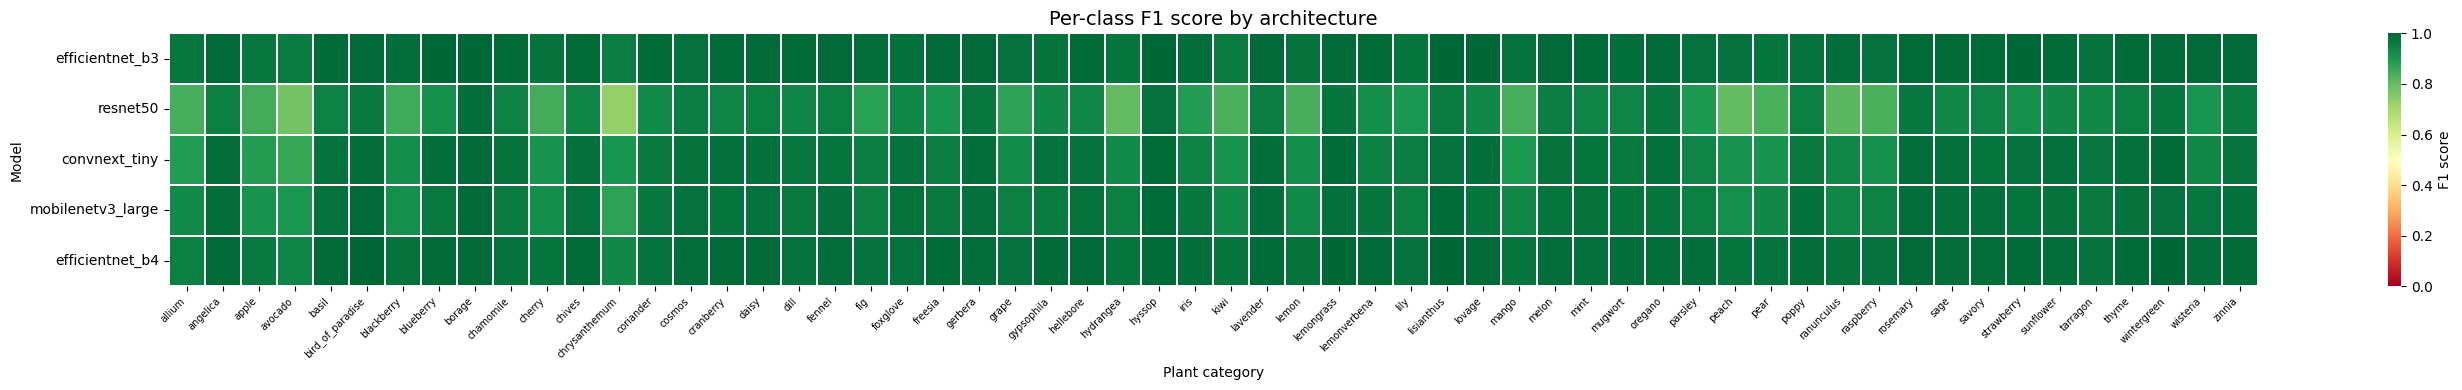

In [38]:
# ============================================
# Per-Class F1 Heatmap  (models × 59 classes)
# ============================================
# Rows = architectures, columns = plant categories.
# Dark cells = low F1 → classes that are consistently hard regardless of model.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

f1_rows = {}
for model_key, preds in all_preds.items():
    f1s = f1_score(y_true_all, preds, average=None, labels=list(range(num_classes)))
    f1_rows[model_key] = f1s

f1_df = pd.DataFrame(f1_rows, index=class_names).T   # shape: (5 models × 59 classes)

fig, ax = plt.subplots(figsize=(28, 4))
sns.heatmap(
    f1_df, annot=False, cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={"label": "F1 score"}
)
ax.set_title("Per-class F1 score by architecture", fontsize=14)
ax.set_xlabel("Plant category")
ax.set_ylabel("Model")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150)
plt.show()

# Log to wandb
diag_run = wandb.init(project="certification", name="model_diagnostics",
                      reinit="finish_previous")
wandb.log({"f1_heatmap": wandb.Image("f1_heatmap.png"),
           "f1_table":   wandb.Table(dataframe=f1_df.reset_index().rename(columns={"index": "model"}))})

In [27]:
len(all_preds['efficientnet_b3'])

11781

In [ ]:
f1_df.to_csv("/content/drive/MyDrive/bootcamp_project/data/f1_df_perclass.csv")

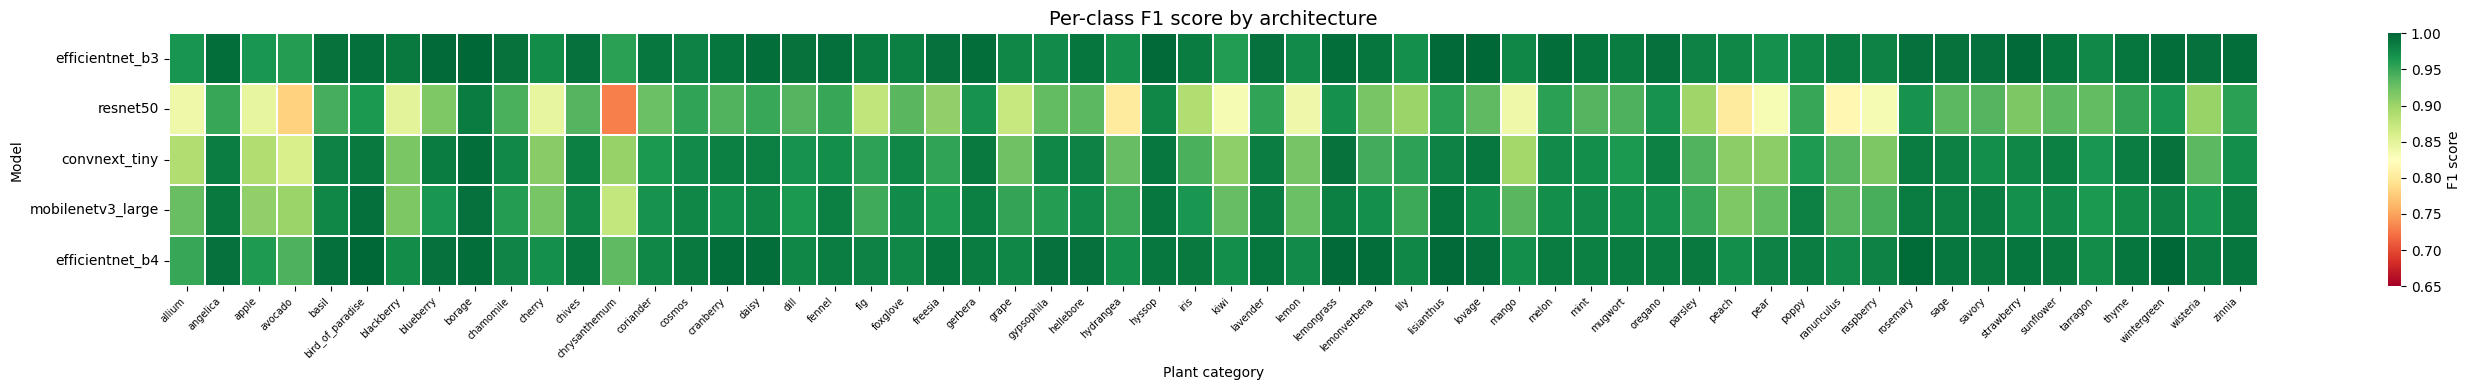

In [22]:
fig, ax = plt.subplots(figsize=(28, 4))
sns.heatmap(
    f1_df, annot=False, cmap="RdYlGn", vmin=0.65, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={"label": "F1 score"}
)
ax.set_title("Per-class F1 score by architecture", fontsize=14)
ax.set_xlabel("Plant category")
ax.set_ylabel("Model")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150)
plt.show()

# Log to wandb
diag_run = wandb.init(project="certification", name="model_diagnostics",
                      reinit="finish_previous")
wandb.log({"f1_heatmap": wandb.Image("f1_heatmap.png"),
           "f1_table":   wandb.Table(dataframe=f1_df.reset_index().rename(columns={"index": "model"}))})

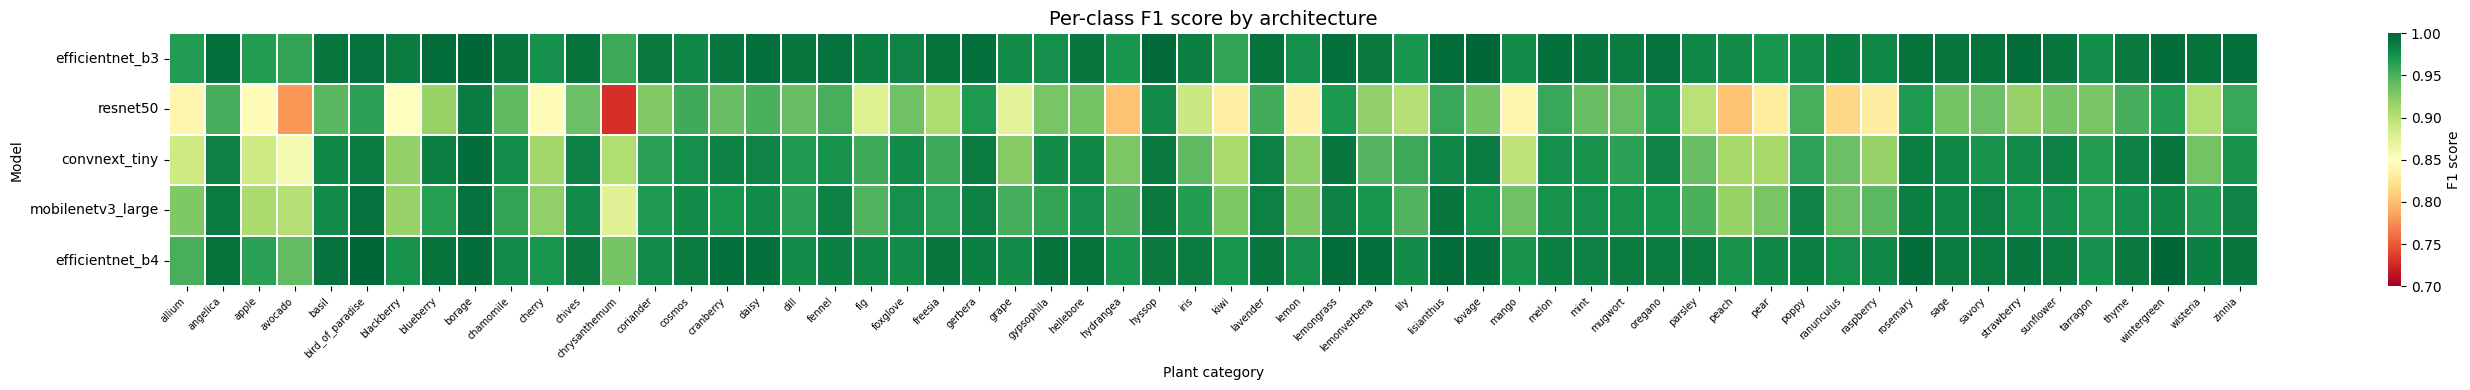

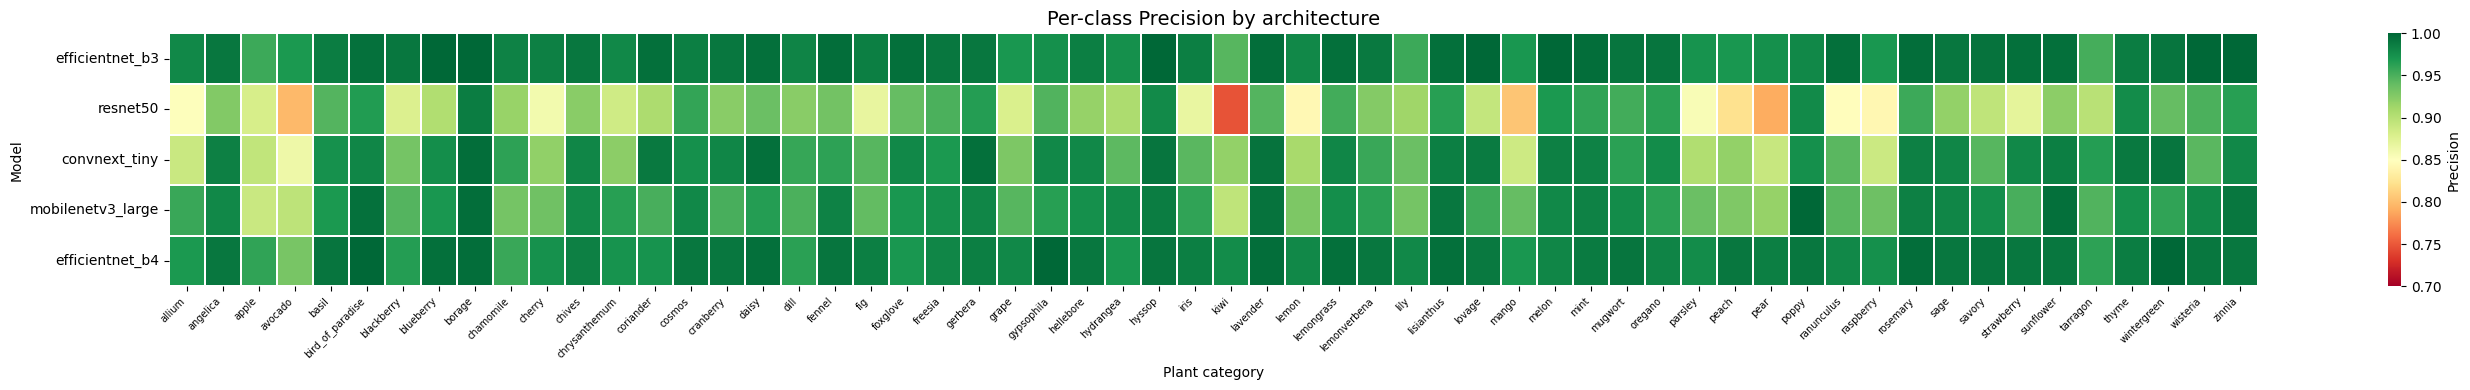

In [23]:
# ============================================
# Per-Class F1 and Precision Heatmaps  (models x 59 classes)
# ============================================
# Rows = architectures, columns = plant categories.
# vmin=0.7 so differences in the weaker classes are visible.
# F1        = harmonic mean of precision & recall — overall quality per class.
# Precision = of all images predicted as class X, how many actually are X.
#             Low precision -> the model over-predicts that class (false positives).

from sklearn.metrics import f1_score, precision_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

f1_rows, prec_rows = {}, {}
for model_key, preds in all_preds.items():
    f1_rows[model_key]   = f1_score(
        y_true_all, preds, average=None, labels=list(range(num_classes)), zero_division=0)
    prec_rows[model_key] = precision_score(
        y_true_all, preds, average=None, labels=list(range(num_classes)), zero_division=0)

f1_df   = pd.DataFrame(f1_rows,   index=class_names).T
prec_df = pd.DataFrame(prec_rows, index=class_names).T


def plot_metric_heatmap(df, title, filename):
    fig, ax = plt.subplots(figsize=(28, 4))
    sns.heatmap(
        df, annot=False, cmap="RdYlGn", vmin=0.7, vmax=1.0,
        linewidths=0.3, ax=ax, cbar_kws={"label": title}
    )
    ax.set_title(f"Per-class {title} by architecture", fontsize=14)
    ax.set_xlabel("Plant category")
    ax.set_ylabel("Model")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


plot_metric_heatmap(f1_df,   "F1 score",  "f1_heatmap.png")
plot_metric_heatmap(prec_df, "Precision", "precision_heatmap.png")

# Log both to wandb
diag_run = wandb.init(project="certification", name="model_diagnostics",
                      reinit="finish_previous")
wandb.log({
    "f1_heatmap":        wandb.Image("f1_heatmap.png"),
    "precision_heatmap": wandb.Image("precision_heatmap.png"),
    "f1_table":          wandb.Table(dataframe=f1_df.reset_index().rename(columns={"index": "model"})),
    "precision_table":   wandb.Table(dataframe=prec_df.reset_index().rename(columns={"index": "model"})),
})

Classes with F1 < 0.8 in 3+ models (0 found):



IndexError: index 0 is out of bounds for axis 0 with size 0

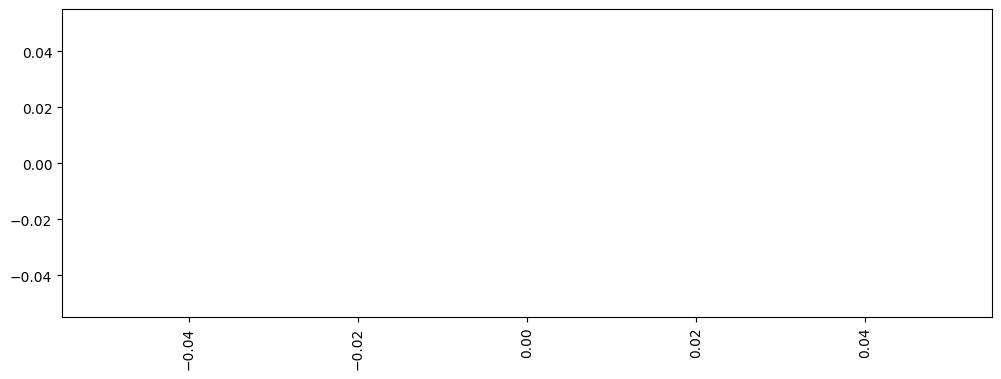

In [24]:
# ============================================
# Consistent Error Analysis
# ============================================
# For each class: how many of the 5 models have F1 < threshold?
# Classes that fail across multiple architectures are intrinsically hard
# (poor image quality, visual similarity to other species) — not a model issue.

FAIL_THRESHOLD = 0.80   # F1 below this is considered a "failure" for that model

fail_counts = (f1_df < FAIL_THRESHOLD).sum(axis=0)   # per class: how many models fail it
hard_classes = fail_counts[fail_counts >= 3].sort_values(ascending=False)

print(f"Classes with F1 < {FAIL_THRESHOLD} in 3+ models ({len(hard_classes)} found):")
print()
for cls, n_fails in hard_classes.items():
    f1s = {m: round(f1_df.loc[m, cls], 3) for m in f1_df.index}
    print(f"  {cls:<25}  failed by {n_fails}/5 models  |  {f1s}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
hard_classes.plot(kind="bar", ax=ax, color="tomato")
ax.axhline(3, color="gray", linestyle="--", linewidth=0.8, label="threshold (3 models)")
ax.set_title(f"Classes with F1 < {FAIL_THRESHOLD} in ≥ 3 models", fontsize=13)
ax.set_ylabel("Number of models failing")
ax.set_xlabel("Plant category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("hard_classes.png", dpi=150)
plt.show()

wandb.log({"hard_classes": wandb.Image("hard_classes.png")})

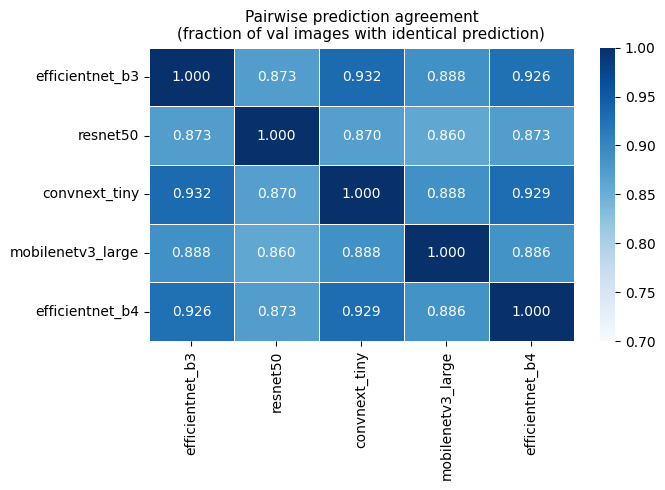


Note: high agreement between two models means they make similar errors.
Low agreement means different failure modes → ensembling would be more beneficial.


In [ ]:
# ============================================
# Pairwise Prediction Agreement
# ============================================
# sklearn.metrics.confusion_matrix(pred_A, pred_B) applied between two models
# (not against ground truth) gives a picture of *where* they disagree.
#
# Here we compute a simpler scalar: % of val images where both models predict
# the same class — regardless of whether that class is correct.
# Low agreement = models make different errors = ensembling could help.
# High agreement = same errors = little benefit from combining them.

from sklearn.metrics import confusion_matrix as skl_cm
from itertools import combinations

model_keys = list(all_preds.keys())
n = len(model_keys)
agreement_mat = np.zeros((n, n))

for i, j in combinations(range(n), 2):
    ka, kb = model_keys[i], model_keys[j]
    agree = (all_preds[ka] == all_preds[kb]).mean()
    agreement_mat[i, j] = agree
    agreement_mat[j, i] = agree
np.fill_diagonal(agreement_mat, 1.0)

agree_df = pd.DataFrame(agreement_mat, index=model_keys, columns=model_keys)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(agree_df, annot=True, fmt=".3f", cmap="Blues",
            vmin=0.7, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title("Pairwise prediction agreement\n(fraction of val images with identical prediction)", fontsize=11)
plt.tight_layout()
plt.savefig("agreement_matrix.png", dpi=150)
plt.show()

print("\nNote: high agreement between two models means they make similar errors.")
print("Low agreement means different failure modes → ensembling would be more beneficial.")
wandb.log({"agreement_matrix": wandb.Image("agreement_matrix.png"),
           "agreement_table":  wandb.Table(dataframe=agree_df.reset_index().rename(columns={"index": "model"}))})

In [ ]:
# ============================================
# McNemar's Test — ConvNeXt-Tiny vs EfficientNet-B3
# ============================================
# McNemar's test checks whether the accuracy difference between two classifiers
# is statistically significant, accounting for the fact that they are evaluated
# on the same images (paired samples).
#
# Null hypothesis H₀: both models make the same number of errors.
# p < 0.05 → the gap is significant and not a sampling artifact.
#
# The 2×2 contingency table:
#   [ both_correct  |  A_correct_B_wrong ]
#   [ A_wrong_B_correct | both_wrong     ]
# Only the off-diagonal cells (b and c) matter for the test.

import scipy.stats as stats

def mcnemar_test(preds_a, preds_b, y_true, name_a="A", name_b="B"):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    b = np.sum( correct_a & ~correct_b)   # A right, B wrong
    c = np.sum(~correct_a &  correct_b)   # A wrong, B right

    # McNemar's statistic with continuity correction (Edwards, 1948)
    chi2    = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
    p_value = 1 - stats.chi2.cdf(chi2, df=1)

    print(f"McNemar's test: {name_a} vs {name_b}")
    print(f"  Contingency table:  b (A✓ B✗) = {b}   c (A✗ B✓) = {c}")
    print(f"  χ² = {chi2:.4f}   p = {p_value:.6f}")
    if p_value < 0.05:
        better = name_a if b > c else name_b
        print(f"  → Significant (p<0.05). {better} is statistically better.")
    else:
        print(f"  → Not significant (p≥0.05). Cannot conclude one is better.")
    print()
    return {"b": int(b), "c": int(c), "chi2": chi2, "p_value": p_value}


# Primary comparison: winner vs runner-up
r1 = mcnemar_test(all_preds["convnext_tiny"], all_preds["efficientnet_b3"],
                  y_true_all, "convnext_tiny", "efficientnet_b3")

# Secondary: runner-up vs third (worth knowing if they are interchangeable)
r2 = mcnemar_test(all_preds["efficientnet_b3"], all_preds["efficientnet_b4"],
                  y_true_all, "efficientnet_b3", "efficientnet_b4")

wandb.log({"mcnemar_convnext_vs_effb3": r1, "mcnemar_effb3_vs_effb4": r2})
diag_run.finish()

McNemar's test: convnext_tiny vs efficientnet_b3
  Contingency table:  b (A✓ B✗) = 468   c (A✗ B✓) = 171
  χ² = 137.1142   p = 0.000000
  → Significant (p<0.05). convnext_tiny is statistically better.

McNemar's test: efficientnet_b3 vs efficientnet_b4
  Contingency table:  b (A✓ B✗) = 335   c (A✗ B✓) = 324
  χ² = 0.1517   p = 0.696873
  → Not significant (p≥0.05). Cannot conclude one is better.

